In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn.compose import ColumnTransformer


from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [7]:
df = pd.read_csv(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\Titanic-Dataset.csv", usecols = ["Age" , "Fare" , "Survived"])

In [8]:
df.sample(3)

,Survived,Age,Fare
358,1,NaN,7.8792
282,0,16.0,9.5000
74,1,32.0,56.4958


In [11]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [10]:
df.dropna(inplace= True)

In [12]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [20]:
X_train , X_test , y_train, y_test = train_test_split(X,y, test_size = 0.25, random_state = 42)

In [21]:
print(X.shape)
print(X_train.shape)

(714, 2)
(535, 2)


In [22]:
Model = DecisionTreeClassifier()

In [23]:
Model.fit(X_train , y_train)
y_pred = Model.predict(X_test)

In [24]:
accuracy_score(y_test , y_pred)

0.6256983240223464

In [26]:
B_age = KBinsDiscretizer(n_bins =10 , encode = "ordinal" , strategy = "quantile")
B_fare = KBinsDiscretizer(n_bins =10 , encode = "ordinal" , strategy = "quantile")

In [28]:
trans = ColumnTransformer([
  ("first" , B_age , [0]),
("Second" , B_fare , [1])
])

In [30]:
X_trained = trans.fit_transform(X_train)
X_tested = trans.fit_transform(X_test)

C:\Users\asifb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\asifb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\asifb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_discretization

In [31]:
X_trained

array([[6., 3.],
       [0., 5.],
       [6., 4.],
       ...,
       [7., 9.],
       [6., 5.],
       [6., 1.]], shape=(535, 2))

In [39]:
trans.named_transformers_["first"].bin_edges_ # 10 % of data in each quantile 

array([array([ 1. , 11. , 18. , 21. , 24. , 27. , 30. , 34. , 38.4, 47.2, 62. ])],
      dtype=object)

In [42]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_trained[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_trained[:,1]
})

In [44]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trans.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trans.named_transformers_['Second'].bin_edges_[0].tolist())

In [45]:
output.head()

,age,age_trf,fare,fare_trf,age_labels,fare_labels
812,35.0,6.0,10.5000,3.0,"(34.0, 38.4]","(8.671, 10.5]"
448,5.0,0.0,19.2583,5.0,"(1.0, 11.0]","(14.454, 21.06]"
657,32.0,6.0,15.5000,4.0,"(30.0, 34.0]","(14.454, 21.06]"
311,18.0,1.0,262.3750,9.0,"(11.0, 18.0]","(58.263, 512.329]"
430,28.0,4.0,26.5500,6.0,"(27.0, 30.0]","(21.06, 27.721]"


In [46]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',B_age,[0]),
        ('second',B_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()
    

C:\Users\asifb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\Users\asifb\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.6274843505477308


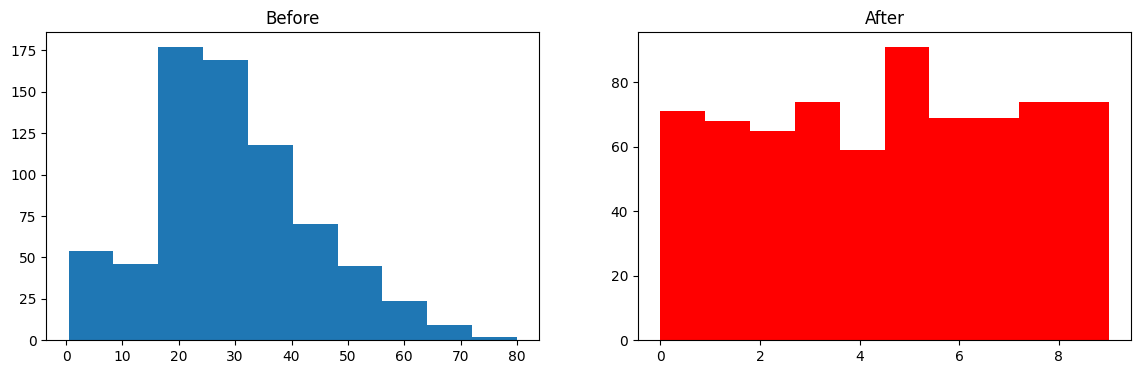

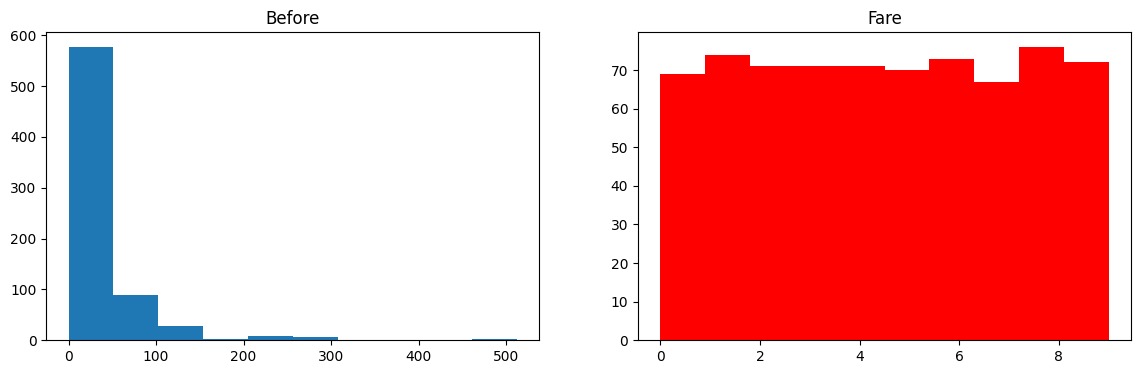

In [50]:
discretize(10, "uniform")

## Handling Mixed Varriables 

In [3]:
df = pd.read_excel(r"C:\Users\asifb\OneDrive\Desktop\Python language\Jupyter Notebook\Kaggle\Titanic part2.xlsx")

In [4]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [6]:
df["number"].value_counts()

number
A    139
6    131
1    129
2    126
4    126
5    123
3    117
Name: count, dtype: int64

In [7]:
# extract numerical part
df["number_numeric"] = pd.to_numeric(df["number"], errors = "coerce" , downcast = "integer")

In [9]:
df["number_categorical"] = np.where(df["number_numeric"].isnull() , df["number"] , np.nan)

In [10]:
df.sample(9)

,Cabin,Ticket,number,Survived,number_numeric,number_categorical
841,NaN,S.O./P.P. 3,3,0,3.0,NaN
630,A23,27042,6,1,6.0,NaN
169,NaN,1601,A,0,NaN,A
696,NaN,363592,A,0,NaN,A
127,NaN,C 17369,4,1,4.0,NaN
234,NaN,C.A. 29566,6,0,6.0,NaN
833,NaN,347468,1,0,1.0,NaN
681,D49,PC 17572,1,1,1.0,NaN
147,NaN,W./C. 6608,5,0,5.0,NaN


In [12]:
df["Cabin"].unique()

<StringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str

In [21]:
df["Cabin_numeric"] = df["Cabin"].str.extract((r"(\d+)"))
df["Cabin_categorical"] = df["Cabin"].str[0]

In [20]:
df = df.drop(columns = ["Cabin_numeric" , "Cabin_categorical"])

In [22]:
df

,Cabin,Ticket,number,Survived,number_numeric,number_categorical,Cabin_numeric,Cabin_categorical
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN
...,...,...,...,...,...,...,...,...
886,NaN,211536,3,0,3.0,NaN,NaN,NaN
887,B42,112053,3,1,3.0,NaN,42,B
888,NaN,W./C. 6607,1,0,1.0,NaN,NaN,NaN
889,C148,111369,2,1,2.0,NaN,148,C


<Axes: xlabel='Cabin_categorical'>

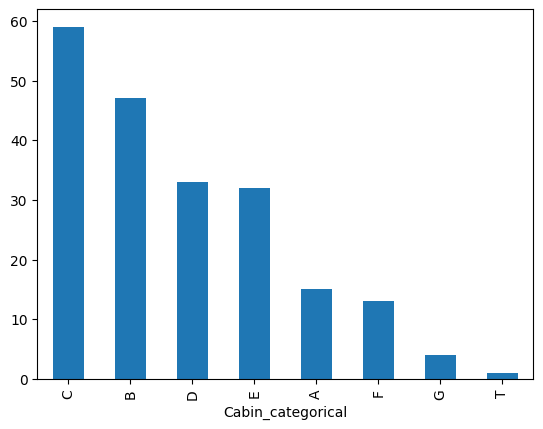

In [25]:
df["Cabin_categorical"].value_counts().plot(kind = "bar")

In [ ]:
_